This notebook defines flooding severity for each gauge according to the Log-Pearson Type III Dsitribution

In [47]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import wandb
import numpy as np
import os
import gc
import re

In [48]:
# Set global row display limit for Polars DataFrames
pl.Config.set_tbl_rows(20)

polars.config.Config

In [49]:
# Connect to Weights and Biases API
api = wandb.Api()

In [116]:
# Load the raw daily streamflow max dataset from wandb
artifact = api.artifact("flood-forecasting/flood-dataset-daily-summary:latest")
artifact_dir = artifact.download()

# Read the parquet file
sfd_df = pl.read_parquet(os.path.join(artifact_dir, "flood_model_daily_summary.parquet"))

# Filter out null values (-999,999) in streamflow_cfs_max
sfd_df = sfd_df.filter(pl.col("streamflow_cfs_max") != -999999)

wandb:   1 of 1 files downloaded.  


In [51]:
print(f"Full dataset: {sfd_df.shape[0]:,} rows x {sfd_df.shape[1]} columns")
print(f"Total sites: {sfd_df['site_id'].n_unique()}")
print(sfd_df.head())
print(f"Date range: {sfd_df['observed_date'].min()} to {sfd_df['observed_date'].max()}")

size_mb = sfd_df.estimated_size("mb")
print(f"{size_mb:.2f} MB")

Full dataset: 4,325,844 rows x 4 columns
Total sites: 1029
shape: (5, 4)
┌──────────┬───────────────┬────────────────────┬────────────────────┐
│ site_id  ┆ observed_date ┆ streamflow_cfs_max ┆ gage_height_ft_max │
│ ---      ┆ ---           ┆ ---                ┆ ---                │
│ str      ┆ date          ┆ f64                ┆ f64                │
╞══════════╪═══════════════╪════════════════════╪════════════════════╡
│ 06017000 ┆ 2015-07-09    ┆ 203.0              ┆ 3.85               │
│ 06017000 ┆ 2015-07-22    ┆ 163.0              ┆ 3.75               │
│ 06017000 ┆ 2015-07-28    ┆ 172.0              ┆ 3.82               │
│ 06017000 ┆ 2015-08-02    ┆ 121.0              ┆ 3.6                │
│ 06017000 ┆ 2015-08-04    ┆ 130.0              ┆ 3.66               │
└──────────┴───────────────┴────────────────────┴────────────────────┘
Date range: 2007-10-28 to 2026-02-06
116.80 MB


The catchment attributes table does not contain data on all sites. Therefore we must use it as a filter.

In [52]:
import duckdb

con = duckdb.connect("../flood_forecasting.duckdb", read_only=True)

ca_df = con.execute("SELECT * FROM main_marts.dim_catchment_attributes_full").pl()
con.close()

print(ca_df.shape)

(9008, 561)


In [53]:
# Function for creating annual peaks DataFrame for Log-Pearson Type III Distribution Fitting

def calc_annual_peaks(df, station_col,streamflow_col, date_col,):
    """
    Takes a polars Dataframe and calculates the annual discharge peaks for each station. 
    
    Inputs:
        df: Polars DataFrame containing streamflow data
        station_col: Name of the column containing station identifiers (e.g., 'site_id')
        streamflow_col: Name of the column containing streamflow values (e.g., 'streamflow_cfs_mean')
        date_col: Name of the column containing date values (e.g., 'date')
    Returns:
        New DataFrame with columns for station_id, year, peak_discharge, and peak_date.
    """
    return (
        df
        .filter(pl.col(streamflow_col).is_not_null()) 
        .filter(pl.col(streamflow_col) > 0) 
        .with_columns([
            # Calculate  year
            pl.when(pl.col(date_col).dt.month() >= 10)
            .then(pl.col(date_col).dt.year() + 1)
            .otherwise(pl.col(date_col).dt.year())
            .alias("year")
        ])
        .group_by([station_col, "year"])
        .agg([
            pl.col(streamflow_col).max().alias("peak_discharge_cfs"),
            pl.col(date_col).sort_by(streamflow_col).last().dt.date().alias("peak_date")
        ])
        .sort([station_col, "year"])
    )

In [54]:
annual_peaks_sfd = calc_annual_peaks(sfd_df, "site_id", "streamflow_cfs_max", "observed_date")

# Remove sites that are not found in the catchment attributes dataset
annual_peaks_sfd = annual_peaks_sfd.join(
    ca_df.select("site_id"),
    on="site_id",
    how="semi"
)



print(f"Annual peaks extracted: {annual_peaks_sfd.shape[0]:,} site-years")
print(annual_peaks_sfd.head())

Annual peaks extracted: 9,774 site-years
shape: (5, 4)
┌──────────┬──────┬────────────────────┬────────────┐
│ site_id  ┆ year ┆ peak_discharge_cfs ┆ peak_date  │
│ ---      ┆ ---  ┆ ---                ┆ ---        │
│ str      ┆ i32  ┆ f64                ┆ date       │
╞══════════╪══════╪════════════════════╪════════════╡
│ 06006000 ┆ 2008 ┆ 156.0              ┆ 2008-06-23 │
│ 06006000 ┆ 2009 ┆ 141.0              ┆ 2009-06-21 │
│ 06006000 ┆ 2010 ┆ 146.0              ┆ 2010-06-05 │
│ 06006000 ┆ 2011 ┆ 245.0              ┆ 2011-06-30 │
│ 06006000 ┆ 2012 ┆ 154.0              ┆ 2012-06-06 │
└──────────┴──────┴────────────────────┴────────────┘


In [55]:
# Create the site mapping from ca_df
site_df = ca_df.select(["site_id", "LAT_GAGE", "LNG_GAGE", "state_gage"]).rename({"LAT_GAGE": "latitude", "LNG_GAGE": "longitude", "state_gage": "state"})

print(site_df.head())

shape: (5, 4)
┌──────────┬───────────┬────────────┬───────┐
│ site_id  ┆ latitude  ┆ longitude  ┆ state │
│ ---      ┆ ---       ┆ ---        ┆ ---   │
│ str      ┆ f64       ┆ f64        ┆ str   │
╞══════════╪═══════════╪════════════╪═══════╡
│ 01015800 ┆ 46.523003 ┆ -68.371764 ┆ ME    │
│ 01016500 ┆ 46.628311 ┆ -68.434792 ┆ ME    │
│ 01017000 ┆ 46.777294 ┆ -68.157194 ┆ ME    │
│ 01017060 ┆ 46.783611 ┆ -67.989167 ┆ ME    │
│ 01017290 ┆ 46.88861  ┆ -67.945    ┆ ME    │
└──────────┴───────────┴────────────┴───────┘


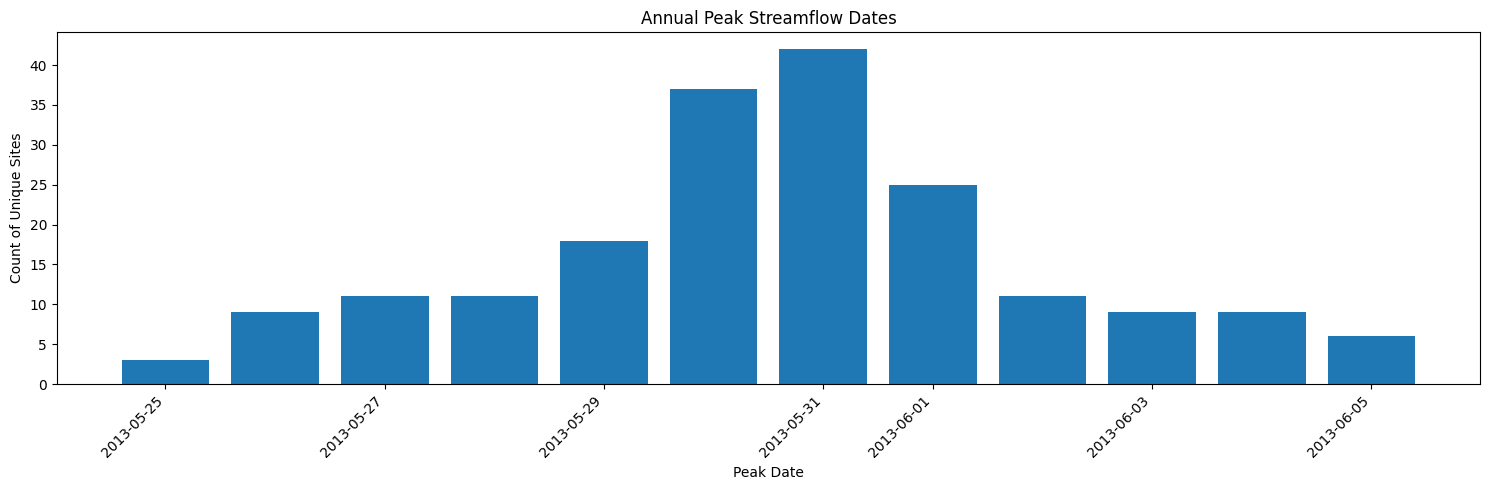

In [56]:
import matplotlib.pyplot as plt
from datetime import date

# Count unique site_ids per peak_date
peak_date_counts = (
    annual_peaks_sfd
    .group_by("peak_date")
    .agg(pl.col("site_id").n_unique().alias("site_count"))
    .sort("peak_date")
)

# Convert to pandas for matplotlib
# Apply date limits on the dataset
pdf = peak_date_counts.filter(
    (pl.col("peak_date") >= date(2013, 5, 25)) & 
    (pl.col("peak_date") <= date(2013, 6, 5))
).to_pandas()

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(pdf["peak_date"], pdf["site_count"])

ax.set_xlabel("Peak Date")
ax.set_ylabel("Count of Unique Sites")
ax.set_title("Annual Peak Streamflow Dates")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Calculate Log-Pearson Type III Distribution Stats for Flood Measurements

In [57]:
# Create dictionary of regional skew values and MSE for Log-Pearson Type III distribution fitting

REGIONAL_SKEW_BY_STATE = {
    # New England (SIR 2017-5037)
    "CT": {"skew": 0.32, "mse": 0.14},  # Connecticut
    "MA": {"skew": 0.32, "mse": 0.14},  # Massachusetts
    "ME": {"skew": 0.02, "mse": 0.09},  # Maine (SIR 2020-5092)
    "NH": {"skew": 0.32, "mse": 0.14},  # New Hampshire
    "RI": {"skew": 0.32, "mse": 0.14},  # Rhode Island
    "VT": {"skew": 0.32, "mse": 0.14},  # Vermont
    
    # Mid-Atlantic
    "NY": {"skew": 0.32, "mse": 0.13},  # New York (eastern)
    "PA": {"skew": 0.32, "mse": 0.13},  # Pennsylvania (eastern)
    "NJ": {"skew": 0.32, "mse": 0.13},  # New Jersey
    "MD": {"skew": 0.50, "mse": 0.17},  # Maryland (Atlantic drainage)
    "DE": {"skew": 0.50, "mse": 0.17},  # Delaware
    
    # Southeast (Atlantic drainage)
    "VA": {"skew": 0.50, "mse": 0.17},  # Virginia (Atlantic drainage)
    "WV": {"skew": 0.50, "mse": 0.17},  # West Virginia (Atlantic) / 0.048 (Gulf)
    "NC": {"skew": 0.40, "mse": 0.15},  # North Carolina
    "SC": {"skew": 0.40, "mse": 0.15},  # South Carolina
    "GA": {"skew": 0.40, "mse": 0.15},  # Georgia
    "FL": {"skew": 0.00, "mse": 0.30},  # Florida
    
    # Gulf States
    "AL": {"skew": 0.10, "mse": 0.17},  # Alabama
    "MS": {"skew": 0.00, "mse": 0.30},  # Mississippi
    "LA": {"skew": -0.10, "mse": 0.30}, # Louisiana
    "TX": {"skew": -0.10, "mse": 0.30}, # Texas
    
    # Great Lakes / Ohio River Basin (SIR 2019-5105)
    "OH": {"skew": 0.086, "mse": 0.11}, # Ohio
    "MI": {"skew": 0.086, "mse": 0.11}, # Michigan
    "IN": {"skew": 0.086, "mse": 0.11}, # Indiana
    "IL": {"skew": 0.086, "mse": 0.11}, # Illinois
    "WI": {"skew": 0.086, "mse": 0.11}, # Wisconsin
    
    # Upper Midwest
    "MN": {"skew": -0.10, "mse": 0.25}, # Minnesota
    "IA": {"skew": -0.20, "mse": 0.25}, # Iowa
    "MO": {"skew": -0.30, "mse": 0.14}, # Missouri (SIR 2014-5165)
    
    # Northern Plains
    "ND": {"skew": -0.30, "mse": 0.30}, # North Dakota
    "SD": {"skew": -0.30, "mse": 0.30}, # South Dakota
    "NE": {"skew": -0.30, "mse": 0.30}, # Nebraska
    "KS": {"skew": -0.20, "mse": 0.30}, # Kansas
    
    # Southern Plains / Gulf drainage
    "OK": {"skew": -0.10, "mse": 0.30}, # Oklahoma
    "AR": {"skew": 0.00, "mse": 0.30},  # Arkansas
    "KY": {"skew": 0.048, "mse": 0.17}, # Kentucky (Gulf drainage)
    "TN": {"skew": 0.048, "mse": 0.17}, # Tennessee
    
    # Rocky Mountain
    "MT": {"skew": -0.20, "mse": 0.30}, # Montana
    "WY": {"skew": -0.10, "mse": 0.30}, # Wyoming
    "CO": {"skew": -0.10, "mse": 0.30}, # Colorado
    "UT": {"skew": -0.20, "mse": 0.30}, # Utah
    "NM": {"skew": -0.20, "mse": 0.30}, # New Mexico
    "AZ": {"skew": -0.30, "mse": 0.30}, # Arizona
    
    # Pacific Northwest (Columbia River Basin - SIR 2020-5073)
    "WA": {"skew": 0.10, "mse": 0.20},  # Washington
    "OR": {"skew": 0.10, "mse": 0.20},  # Oregon
    "ID": {"skew": 0.00, "mse": 0.20},  # Idaho
    
    # Pacific
    "CA": {"skew": -0.10, "mse": 0.15}, # California (varies by region)
    "NV": {"skew": -0.30, "mse": 0.30}, # Nevada
    
    # Alaska and Hawaii
    "AK": {"skew": -0.30, "mse": 0.30}, # Alaska (use with caution)
    "HI": {"skew": 0.00, "mse": 0.30},  # Hawaii (use with caution)
}

DEFAULT_REGIONAL_SKEW = {"skew": -0.20, "mse": 0.302}

In [58]:
def get_regional_skew(state_abbrev: str) -> tuple[float, float]:
    """
    Get regional skew coefficient and MSE for a given state.
    
    Inputs:
        state_abbrev : str
            Two-letter state abbreviation (e.g., 'CA', 'TX', 'NY')
    
    Output:
        tuple[float, float] : (regional_skew, regional_mse)
    """
    state = state_abbrev.upper()
    skew_dict = REGIONAL_SKEW_BY_STATE.get(state, DEFAULT_REGIONAL_SKEW)
    return skew_dict["skew"], skew_dict["mse"]

In [59]:
def calc_station_skew_mse(station_skew, n_years):
    """
    Approximation for station skew MSE that accounts for skewness.
    
    Inputs:
        station_skew : float
            G (gamma hat) - the sample skewness of log-transformed peaks
        n_years : int
            Number of years of record
    Outputs:
        Mean Squared Error (MSE) of the station skew estimate, accounting for skewness and sample size.
    """
    G = station_skew  
    n = n_years
    
    mse = ((6/n) + (9/n**2) + (15*G**2/n) + (10*G**2/n**2)) / (1 + 0.75*G**2)**2
    
    return mse

In [60]:
def calc_weighted_skew(station_skew, station_mse, regional_skew, regional_mse):
    """
    Calculate weighted skew using inverse MSE weighting per Bulletin 17C.
    
    Inputs:
        station_skew
            Station skew coefficient (G)
        station_mse
            MSE of station skew
        regional_skew
            Regional skew coefficient
        regional_mse
            MSE of regional skew
    
    Outputs:
        Gfloat : Weighted skew coefficient
    """
    # Inverse MSE weighting
    weight_station = regional_mse / (station_mse + regional_mse)
    weight_regional = station_mse / (station_mse + regional_mse)
    
    weighted_skew = weight_station * station_skew + weight_regional * regional_skew
    
    return weighted_skew

In [61]:
def calc_mgb_critical_value(n: int, alpha: float = 0.10) -> float:
    """
    Calculate the Grubbs-Beck critical value K_n for sample size n and significance level alpha.
    
    Parameters:
    -----------
    n : int
        Sample size (number of years)
    alpha : float
        Significance level (default 0.10 for MGB test)
    
    Returns:
    --------
    float
        Critical value K_n
    """
    
    if n < 10:
        return np.nan
    
    # Grubbs-Beck critical value using t-distribution
    # K_n = t_(alpha/n, n-2) * sqrt((n-1) / (n - 2 + t^2))
    t_crit = stats.t.ppf(1 - alpha / n, df=n - 2)
    K_n = t_crit * np.sqrt((n - 1) / (n - 2 + t_crit**2))
    
    return K_n

In [62]:
def calc_mgb_threshold(peaks: np.ndarray, alpha: float = 0.10, max_iterations: int = 50) -> dict:
    """
    Calculate the Multiple Grubbs-Beck PILF threshold iteratively.
    """
    valid_peaks = peaks[peaks > 0]
    if len(valid_peaks) < 10:
        return {
            "pilf_threshold_cfs": np.nan,
            "pilf_threshold_log": np.nan,
            "n_pilfs": 0,
            "n_retained": len(valid_peaks)
        }
    
    log_peaks = np.log10(valid_peaks)
    working_logs = np.sort(log_peaks)
    n_original = len(working_logs)
    n_pilfs = 0
    
    for iteration in range(max_iterations):
        n = len(working_logs)
        if n < 10:
            break
        
        mean_log = np.mean(working_logs)
        std_log = np.std(working_logs, ddof=1)
        
        if std_log == 0:
            break
        
        K_n = calc_mgb_critical_value(n, alpha)
        threshold_log = mean_log - K_n * std_log
        
        if working_logs[0] < threshold_log:
            working_logs = working_logs[working_logs >= threshold_log]
            n_removed = n - len(working_logs)
            n_pilfs += n_removed
        else:
            break
    
    if len(working_logs) >= 10:
        mean_log = np.mean(working_logs)
        std_log = np.std(working_logs, ddof=1)
        K_n = calc_mgb_critical_value(len(working_logs), alpha)
        final_threshold_log = mean_log - K_n * std_log
        final_threshold_cfs = 10 ** final_threshold_log
    else:
        final_threshold_log = np.nan
        final_threshold_cfs = np.nan
    
    return {
        "pilf_threshold_cfs": final_threshold_cfs,
        "pilf_threshold_log": final_threshold_log,
        "n_pilfs": n_pilfs,
        "n_retained": n_original - n_pilfs
    }

In [63]:
from scipy import stats
from scipy.stats import pearson3

def calc_lp3_quantile(mean_log, std_log, skew, return_period):
    """
    Calculate flood discharge for a given return period using LP3 distribution.
    
    Inputs:
    mean_log : float
        Mean of log-transformed peak flows
    std_log : float
        Standard deviation of log-transformed peak flows
    skew : float
        Skew coefficient (weighted or station)
    return_period : int
        Return period in years (e.g., 10, 50, 100)
    
    Returns:
    --------
    float : Estimated discharge in cfs
    """
    p = 1 - 1/return_period  # Non-exceedance probability
    
    # Use scipy's pearson3.ppf for the frequency factor
    log_Q = pearson3.ppf(p, skew, loc=mean_log, scale=std_log)
    
    # Back-transform to cfs
    Q = 10 ** log_Q
    
    return Q

In [64]:
def calc_lp3_analysis(
    annual_peaks_df: pl.DataFrame,
    site_df: pl.DataFrame,
    station_col: str = "site_id",
    discharge_col: str = "peak_discharge_cfs",
    year_col: str = "year",
    state_col: str = "state_gage",
    min_years: int = 10,
    return_periods: list = [2, 5, 10, 25, 50, 100],
    calc_mgb: bool = True,
    mgb_alpha: float = 0.10
) -> pl.DataFrame:
    """
    Calculate LP3 flood frequency analysis for multiple sites.
    
    Inputs:
        annual_peaks_df : pl.DataFrame
            DataFrame with columns [site_id, year, peak_discharge_cfs]
        site_state_df : pl.DataFrame
            DataFrame with columns [site_id, state_gage, LAT_GAGE, LNG_GAGE]
        station_col : str
            Name of station ID column
        discharge_col : str
            Name of discharge column
        year_col : str
            Name of year column
        state_col : str
            Name of state column in site_state_df
        min_years : int
            Minimum years of record required
        return_periods : list
            Return periods to calculate quantiles for
        calc_mgb : bool
            Whether to calculate MGB/PILF threshold (default True)
        mgb_alpha : float
            Significance level for MGB test (default 0.10)
    
    Outputs:
        pl.DataFrame
            Results with LP3 parameters, quantiles, flood counts, and optionally MGB threshold
    """
    
    results = []
    sites = annual_peaks_df[station_col].unique().to_list()
    
    for site_id in sites:
        # Filter data for this site
        site_data = (
            annual_peaks_df
            .filter(pl.col(station_col) == site_id)
            .filter(pl.col(discharge_col).is_not_null())
            .filter(pl.col(discharge_col) > 0)
        )
        
        n_years = site_data.shape[0]
        
        if n_years < min_years:
            continue
        
        # Get peaks as numpy array
        peaks = site_data[discharge_col].to_numpy()
        log_peaks = np.log10(peaks)
        
        # Get state and coordinates
        site_info = site_df.filter(pl.col(station_col) == site_id)
        if site_info.shape[0] == 0:
            continue
        
        state = site_info[state_col].to_list()[0]
        
        # Calculate statistics
        mean_log = np.mean(log_peaks)
        std_log = np.std(log_peaks, ddof=1)
        
        # Station skew
        n = len(log_peaks)
        station_skew = stats.skew(log_peaks, bias=False)
        
        # Station skew MSE (Griffis & Stedinger 2009)
        G = station_skew
        station_mse = ((6/n) + (9/n**2) + (15*G**2/n) + (10*G**2/n**2)) / (1 + 0.75*G**2)**2
        
        # Regional skew
        regional_skew, regional_mse = get_regional_skew(state)
        
        # Weighted skew
        weight_station = regional_mse / (station_mse + regional_mse)
        weight_regional = station_mse / (station_mse + regional_mse)
        weighted_skew = weight_station * station_skew + weight_regional * regional_skew
        
        # Build row
        row = {
            station_col: site_id,
            "state": state,
            "n_years": n_years,
            "mean_log": mean_log,
            "std_log": std_log,
            "station_skew": station_skew,
            "station_mse": station_mse,
            "regional_skew": regional_skew,
            "regional_mse": regional_mse,
            "weighted_skew": weighted_skew
        }
        
        # MGB/PILF calculation
        if calc_mgb:
            mgb_results = calc_mgb_threshold(peaks, alpha=mgb_alpha)
            row["pilf_threshold_cfs"] = mgb_results["pilf_threshold_cfs"]
            row["pilf_threshold_log"] = mgb_results["pilf_threshold_log"]
            row["n_pilfs"] = mgb_results["n_pilfs"]
            row["n_retained"] = mgb_results["n_retained"]
        
        # Calculate quantiles for each return period
        for T in return_periods:
            aep = 1 / T
            non_exceedance_prob = 1 - aep
            log_Q = pearson3.ppf(non_exceedance_prob, weighted_skew, loc=mean_log, scale=std_log)
            Q = 10 ** log_Q
            row[f"Q{T}_cfs"] = Q
            row[f"floods_Q{T}"] = int(np.sum(peaks >= Q))
        
        results.append(row)
    
    return pl.DataFrame(results)

In [65]:
# Run the LP3 analysis
lp3_results = calc_lp3_analysis(
    annual_peaks_df=annual_peaks_sfd,
    site_df=site_df,
    station_col="site_id",
    discharge_col="peak_discharge_cfs",
    state_col="state",
    return_periods=[2, 5, 10, 25, 50, 100],
    min_years=10
)



In [ ]:
# Add the latitude and longitude from site_df to the results for mapping and spatial analysis
lp3_results = lp3_results.join(
    site_df.select(["site_id", "latitude", "longitude"]),
    on="site_id",
    how="left"
)

with pl.Config(tbl_cols=-1):
    print(lp3_results.head()

shape: (5, 28)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ sit ┆ sta ┆ n_y ┆ mea ┆ std ┆ sta ┆ sta ┆ reg ┆ reg ┆ wei ┆ pil ┆ pil ┆ n_p ┆ n_r ┆ Q2_ ┆ flo ┆ Q5_ ┆ flo ┆ Q10 ┆ flo ┆ Q25 ┆ flo ┆ Q50 ┆ flo ┆ Q10 ┆ flo ┆ lat ┆ lon │
│ e_i ┆ te  ┆ ear ┆ n_l ┆ _lo ┆ tio ┆ tio ┆ ion ┆ ion ┆ ght ┆ f_t ┆ f_t ┆ ilf ┆ eta ┆ cfs ┆ ods ┆ cfs ┆ ods ┆ _cf ┆ ods ┆ _cf ┆ ods ┆ _cf ┆ ods ┆ 0_c ┆ ods ┆ itu ┆ git │
│ d   ┆ --- ┆ s   ┆ og  ┆ g   ┆ n_s ┆ n_m ┆ al_ ┆ al_ ┆ ed_ ┆ hre ┆ hre ┆ s   ┆ ine ┆ --- ┆ _Q2 ┆ --- ┆ _Q5 ┆ s   ┆ _Q1 ┆ s   ┆ _Q2 ┆ s   ┆ _Q5 ┆ fs  ┆ _Q1 ┆ de  ┆ ude │
│ --- ┆ str ┆ --- ┆ --- ┆ --- ┆ kew ┆ se  ┆ ske ┆ mse ┆ ske ┆ sho ┆ sho ┆ --- ┆ d   ┆ f64 ┆ --- ┆ f64 ┆ --- ┆ --- ┆ 0   ┆ --- ┆ 5   ┆ --- ┆ 0   ┆ --- ┆ 00  ┆ --- ┆ --- │
│ str ┆     ┆ i64 ┆ f64 ┆ f64 ┆ --- ┆ --- ┆ w   ┆ --- ┆ w   ┆ ld_ ┆ ld_ ┆ i64 ┆ --- ┆     ┆ i64 ┆     ┆ i64 ┆ f64 ┆ --- ┆ f64 ┆ --- ┆ f

In [67]:
with pl.Config(tbl_cols=-1):
    print(lp3_results.filter(pl.col("site_id") == "06926000"))

shape: (1, 28)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ sit ┆ sta ┆ n_y ┆ mea ┆ std ┆ sta ┆ sta ┆ reg ┆ reg ┆ wei ┆ pil ┆ pil ┆ n_p ┆ n_r ┆ Q2_ ┆ flo ┆ Q5_ ┆ flo ┆ Q10 ┆ flo ┆ Q25 ┆ flo ┆ Q50 ┆ flo ┆ Q10 ┆ flo ┆ lat ┆ lon │
│ e_i ┆ te  ┆ ear ┆ n_l ┆ _lo ┆ tio ┆ tio ┆ ion ┆ ion ┆ ght ┆ f_t ┆ f_t ┆ ilf ┆ eta ┆ cfs ┆ ods ┆ cfs ┆ ods ┆ _cf ┆ ods ┆ _cf ┆ ods ┆ _cf ┆ ods ┆ 0_c ┆ ods ┆ itu ┆ git │
│ d   ┆ --- ┆ s   ┆ og  ┆ g   ┆ n_s ┆ n_m ┆ al_ ┆ al_ ┆ ed_ ┆ hre ┆ hre ┆ s   ┆ ine ┆ --- ┆ _Q2 ┆ --- ┆ _Q5 ┆ s   ┆ _Q1 ┆ s   ┆ _Q2 ┆ s   ┆ _Q5 ┆ fs  ┆ _Q1 ┆ de  ┆ ude │
│ --- ┆ str ┆ --- ┆ --- ┆ --- ┆ kew ┆ se  ┆ ske ┆ mse ┆ ske ┆ sho ┆ sho ┆ --- ┆ d   ┆ f64 ┆ --- ┆ f64 ┆ --- ┆ --- ┆ 0   ┆ --- ┆ 5   ┆ --- ┆ 0   ┆ --- ┆ 00  ┆ --- ┆ --- │
│ str ┆     ┆ i64 ┆ f64 ┆ f64 ┆ --- ┆ --- ┆ w   ┆ --- ┆ w   ┆ ld_ ┆ ld_ ┆ i64 ┆ --- ┆     ┆ i64 ┆     ┆ i64 ┆ f64 ┆ --- ┆ f64 ┆ --- ┆ f

Count Flooding Events for each Time Period's Streamflow Threshold

In [68]:
def count_floods_by_quantile(
    annual_peaks_df: pl.DataFrame,
    lp3_results: pl.DataFrame,
    station_col: str = "site_id",
    discharge_col: str = "peak_discharge_cfs"
) -> pl.DataFrame:
    """
    Count the number of annual peaks that exceed each quantile threshold.
    
    Parameters:
    -----------
    annual_peaks_df : pl.DataFrame
        DataFrame with columns [site_id, year, peak_discharge_cfs]
    lp3_results : pl.DataFrame
        DataFrame with LP3 quantiles (Q2_cfs, Q5_cfs, etc.)
    station_col : str
        Name of site ID column
    discharge_col : str
        Name of discharge column
    
    Returns:
    --------
    pl.DataFrame : lp3_results with flood count columns added
    """
    
    # Identify quantile columns
    q_columns = [col for col in lp3_results.columns if col.startswith("Q") and col.endswith("_cfs")]
    
    flood_counts = []
    
    for row in lp3_results.iter_rows(named=True):
        site_id = row[station_col]
        
        # Get peak discharges for this site
        site_peaks = (
            annual_peaks_df
            .filter(pl.col(station_col) == site_id)
            .filter(pl.col(discharge_col).is_not_null())
            .select(discharge_col)
            .to_numpy()
            .flatten()
        )
        
        counts = {station_col: site_id}
        
        # Count floods exceeding each quantile
        for q_col in q_columns:
            threshold = row[q_col]
            if threshold is not None:
                count = int(np.sum(site_peaks >= threshold))
            else:
                count = None
            
            # Create column name (e.g., Q10_cfs -> floods_Q10)
            return_period = q_col.replace("_cfs", "").replace("Q", "")
            counts[f"floods_Q{return_period}"] = count
        
        flood_counts.append(counts)
    
    flood_counts_df = pl.DataFrame(flood_counts)
    
    # Join flood counts to lp3_results
    result = lp3_results.join(
        flood_counts_df,
        on=station_col,
        how="left"
    )
    
    return result


# Run the function
lp3_results = count_floods_by_quantile(
    annual_peaks_df=annual_peaks_sfd,
    lp3_results=lp3_results,
    station_col="site_id",
    discharge_col="peak_discharge_cfs"
)

with pl.Config(tbl_cols=-1):
    print(lp3_results.head(10))

shape: (10, 34)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ sit ┆ sta ┆ n_y ┆ mea ┆ std ┆ sta ┆ sta ┆ reg ┆ reg ┆ wei ┆ pil ┆ pil ┆ n_p ┆ n_r ┆ Q2_ ┆ flo ┆ Q5_ ┆ flo ┆ Q10 ┆ flo ┆ Q25 ┆ flo ┆ Q50 ┆ flo ┆ Q10 ┆ flo ┆ lat ┆ lon ┆ flo ┆ flo ┆ flo ┆ flo ┆ flo ┆ flo │
│ e_i ┆ te  ┆ ear ┆ n_l ┆ _lo ┆ tio ┆ tio ┆ ion ┆ ion ┆ ght ┆ f_t ┆ f_t ┆ ilf ┆ eta ┆ cfs ┆ ods ┆ cfs ┆ ods ┆ _cf ┆ ods ┆ _cf ┆ ods ┆ _cf ┆ ods ┆ 0_c ┆ ods ┆ itu ┆ git ┆ ods ┆ ods ┆ ods ┆ ods ┆ ods ┆ ods │
│ d   ┆ --- ┆ s   ┆ og  ┆ g   ┆ n_s ┆ n_m ┆ al_ ┆ al_ ┆ ed_ ┆ hre ┆ hre ┆ s   ┆ ine ┆ --- ┆ _Q2 ┆ --- ┆ _Q5 ┆ s   ┆ _Q1 ┆ s   ┆ _Q2 ┆ s   ┆ _Q5 ┆ fs  ┆ _Q1 ┆ de  ┆ ude ┆ _Q2 ┆ _Q5 ┆ _Q1 ┆ _Q2 ┆ _Q5 ┆ _Q1 │
│ --- ┆ str ┆ --- ┆ --- ┆ --- ┆ kew ┆ se  ┆ ske ┆ mse ┆ ske ┆ sho ┆ sho ┆ --- ┆ d   ┆ f64 ┆ --- ┆ f64 ┆ --- ┆ --- ┆ 0   ┆ --- ┆ 5   ┆ --- ┆ 0   ┆ --- ┆ 00  ┆ --

Plot Flooding Event Histrograms

In [69]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_flood_count_histograms(lp3_results: pl.DataFrame):
    """
    Create histograms showing the distribution of flood counts across sites for each quantile.
    Auto-detects return periods from column names starting with 'floods_Q'.
    
    Parameters:
    -----------
    lp3_results : pl.DataFrame
        DataFrame with flood count columns (floods_Q2, floods_Q5, etc.)
    """
    
    # Auto-detect flood count columns and extract return periods
    flood_columns = [col for col in lp3_results.columns if re.match(r"^floods_Q\d+$", col)]
    return_periods = [int(col.replace("floods_Q", "")) for col in flood_columns]
    return_periods.sort()
    
    n_plots = len(return_periods)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for i, T in enumerate(return_periods):
        col_name = f"floods_Q{T}"
        
        # Get data
        flood_counts = lp3_results[col_name].drop_nulls().to_numpy()
        
        # Create histogram
        ax = axes[i]
        max_floods = int(max(flood_counts)) if len(flood_counts) > 0 else 1
        bins = range(0, max_floods + 2)
        
        n, bins_out, patches = ax.hist(
            flood_counts, 
            bins=bins, 
            edgecolor="black", 
            color="steelblue", 
            alpha=0.7, 
            align="left"
        )
        
        ax.set_xlabel("Number of Floods")
        ax.set_ylabel("Number of Stations")
        ax.set_title(f"Q{T} ({T}-Year Floods)")
        ax.grid(True, alpha=0.3)

        # Force integer ticks on x-axis
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        
        # Add summary statistics
        total_stations = len(flood_counts)
        mean_floods = flood_counts.mean()
        max_floods_val = flood_counts.max()
        sites_with_zero = (flood_counts == 0).sum()
        sites_with_floods = total_stations - sites_with_zero
        
        stats_text = (
            f"Stations: {total_stations}\n"
            f"With ≥1: {sites_with_floods}\n"
            f"Mean: {mean_floods:.1f}\n"
            f"Max: {max_floods_val}"
        )
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
                verticalalignment="top", horizontalalignment="right",
                fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle("Distribution of Flood Counts Across Stations by Return Period", fontsize=14)
    plt.tight_layout()
    plt.show()

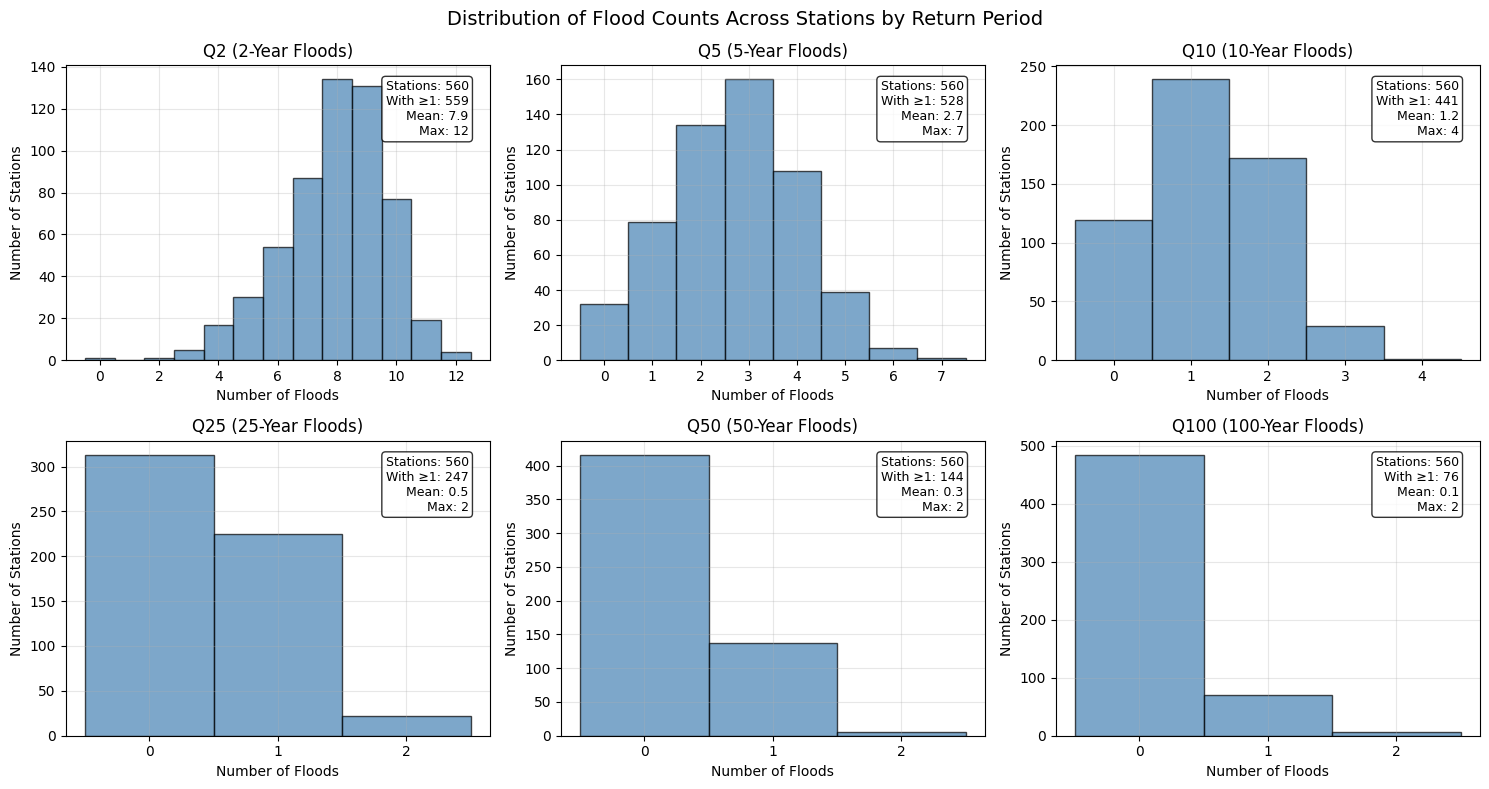

In [70]:
# Run the function
plot_flood_count_histograms(lp3_results)

In [125]:
import plotly.express as px
import numpy as np

def plot_gauge_locations(df, title_text, color_variable, colorscale_text, color_min=None, color_max=None, log_scale=False):
    # Filter data based on color variable limits
    filtered_df = df
    
    if color_min is not None:
        filtered_df = filtered_df.filter(pl.col(color_variable) >= color_min)
    
    if color_max is not None:
        filtered_df = filtered_df.filter(pl.col(color_variable) <= color_max)
    
    # Print number of sites
    n_original = df.shape[0]
    n_filtered = filtered_df.shape[0]
    n_removed = n_original - n_filtered
    
    print(f"Sites: {n_filtered:,} of {n_original:,} ({n_removed:,} removed)")
    
    # Convert to pandas for plotly
    plot_df = filtered_df.to_pandas()
    
    # Create log-transformed column if needed
    if log_scale:
        log_col = f"{color_variable}_log"
        plot_df[log_col] = np.log10(plot_df[color_variable])
        color_col = log_col
    else:
        color_col = color_variable
    
    fig = px.scatter_geo(
        plot_df,
        lat="latitude",
        lon="longitude",
        color=color_col,
        color_continuous_scale="Viridis",
        scope="usa",
        hover_name="site_id",
        title=title_text,
    )
    
    # Update colorbar labels for log scale
    if log_scale:
        # Get tick values in log space
        min_val = plot_df[color_variable].min()
        max_val = plot_df[color_variable].max()
        log_min = np.floor(np.log10(min_val))
        log_max = np.ceil(np.log10(max_val))
        tick_vals = np.arange(log_min, log_max + 1)
        tick_text = [f"{10**v:,.0f}" for v in tick_vals]
        
        fig.update_coloraxes(
            colorbar_title=colorscale_text,
            colorbar_tickvals=tick_vals,
            colorbar_ticktext=tick_text
        )
    else:
        fig.update_coloraxes(colorbar_title=colorscale_text)

    fig.update_layout(geo=dict(
        showland=True,
        showlakes=True,
        showsubunits=True,
        subunitcolor="gray"
    ))

    fig.update_layout(
        title_x=0.5,
        margin={"r": 0, "t": 30, "l": 20, "b": 0}
    )

    fig.show()

In [127]:
# Plot the count of 2 year floods by gauge location
plot_gauge_locations(lp3_results, "Count of 2 Year Floods by Gauge Location", "floods_Q2", "Flood Count (Q2)", 8, None,False)

Sites: 365 of 560 (195 removed)


In [128]:
# Plot the count of 5 year floods by gauge location
plot_gauge_locations(lp3_results, "Count of 5 Year Floods by Gauge Location", "floods_Q5", "Flood Count (Q5)", 5, None, False)

Sites: 47 of 560 (513 removed)


In [133]:
# Plot the count of 10 year floods by gauge location
plot_gauge_locations(lp3_results, "Count of 10 Year Floods by Gauge Location", "floods_Q10", "Flood Count (Q10)", 0, None, False)

Sites: 560 of 560 (0 removed)


In [130]:
# Plot the count of 25 year floods by gauge location
plot_gauge_locations(lp3_results, "Count of 25 Year Floods by Gauge Location", "floods_Q25", "Flood Count (Q25)", 1, None, False)

Sites: 247 of 560 (313 removed)


In [131]:
# Plot the count of 50 year floods by gauge location
plot_gauge_locations(lp3_results, "Count of 50 Year Floods by Gauge Location", "floods_Q50", "Flood Count (Q50)", 1, None, False)

Sites: 144 of 560 (416 removed)


In [132]:
# Plot the count of 10 year flood thresholds by gauge location
plot_gauge_locations(lp3_results, "10 Year Flood Thresholds by Gauge Location", "Q10_cfs", "Q10 (cfs)", 0, None, True)

Sites: 560 of 560 (0 removed)


In [77]:
from matplotlib.ticker import ScalarFormatter, FuncFormatter, LogLocator

def plot_flood_frequency_curve(
    annual_peaks_df: pl.DataFrame,
    lp3_results: pl.DataFrame,
    site_id: str,
    station_col: str = "site_id",
    discharge_col: str = "peak_discharge_cfs"
):
    """
    Plot annual peak discharge vs annual exceedance probability for a specific site.
    Highlights PILF observations and threshold.
    """
    from matplotlib.ticker import FixedLocator, FuncFormatter
    
    # Get LP3 parameters for this site
    site_params = lp3_results.filter(pl.col(station_col) == site_id)
    
    if site_params.shape[0] == 0:
        print(f"Site {site_id} not found in lp3_results")
        return
    
    # Extract parameters
    mean_log = site_params["mean_log"].to_list()[0]
    std_log = site_params["std_log"].to_list()[0]
    weighted_skew = site_params["weighted_skew"].to_list()[0]
    n_years = site_params["n_years"].to_list()[0]
    state = site_params["state"].to_list()[0]
    
    # Get PILF threshold if available
    pilf_threshold = None
    n_pilfs = 0
    if "pilf_threshold_cfs" in site_params.columns:
        pilf_threshold = site_params["pilf_threshold_cfs"].to_list()[0]
        n_pilfs = site_params["n_pilfs"].to_list()[0]
    
    # Get observed peaks for this site
    site_peaks = (
        annual_peaks_df
        .filter(pl.col(station_col) == site_id)
        .filter(pl.col(discharge_col).is_not_null())
        .filter(pl.col(discharge_col) > 0)
        .select(discharge_col)
        .to_numpy()
        .flatten()
    )
    
    # Sort peaks in descending order for plotting positions
    sorted_peaks = np.sort(site_peaks)[::-1]
    n = len(sorted_peaks)
    
    # Weibull plotting positions (AEP in %)
    ranks = np.arange(1, n + 1)
    aep_observed = (ranks / (n + 1)) * 100
    
    # Separate PILF and non-PILF points
    if pilf_threshold is not None and not np.isnan(pilf_threshold):
        is_pilf = sorted_peaks < pilf_threshold
        pilf_peaks = sorted_peaks[is_pilf]
        pilf_aep = aep_observed[is_pilf]
        non_pilf_peaks = sorted_peaks[~is_pilf]
        non_pilf_aep = aep_observed[~is_pilf]
    else:
        non_pilf_peaks = sorted_peaks
        non_pilf_aep = aep_observed
        pilf_peaks = np.array([])
        pilf_aep = np.array([])
    
    # Generate LP3 frequency curve
    aep_curve = np.array([0.1, 0.2, 0.5, 1, 2, 4, 10, 20, 50, 80, 90, 95, 99])
    exceedance_probs = aep_curve / 100
    non_exceedance_probs = 1 - exceedance_probs
    
    log_Q_curve = pearson3.ppf(non_exceedance_probs, weighted_skew, loc=mean_log, scale=std_log)
    Q_curve = 10 ** log_Q_curve
    
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Plot non-PILF observed data points
    ax.scatter(
        non_pilf_aep,
        non_pilf_peaks,
        color="steelblue",
        s=50,
        edgecolor="black",
        linewidth=0.5,
        label="Observed Annual Peaks",
        zorder=3
    )
    
    # Plot PILF points (highlighted)
    if len(pilf_peaks) > 0:
        ax.scatter(
            pilf_aep,
            pilf_peaks,
            color="orange",
            s=70,
            edgecolor="red",
            linewidth=1.5,
            marker="v",
            label=f"PILF Observations (n={len(pilf_peaks)})",
            zorder=4
        )
    
    # Plot LP3 frequency curve
    ax.plot(
        aep_curve,
        Q_curve,
        color="darkred",
        linewidth=2,
        label="LP3 Frequency Curve",
        zorder=2
    )
        
    # Set log scale for y-axis
    ax.set_yscale("log")

    # Force standard number format (no scientific notation)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.yaxis.set_minor_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
    
    # Set x-axis to probability scale (reversed)
    ax.set_xscale("log")
    ax.invert_xaxis()
    
    # Format x-axis as percentages
    tick_positions = [0.2, 0.5, 1, 2, 5, 10, 20, 50, 100]
    ax.xaxis.set_major_locator(FixedLocator(tick_positions))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}%"))
    
    # Labels and title
    ax.set_xlabel("Annual Exceedance Probability (%)", fontsize=12)
    ax.set_ylabel("Peak Discharge (cfs)", fontsize=12)
    ax.set_title(f"Flood Frequency Curve - Site {site_id}", fontsize=14)
    
    # Statistics box
    stats_text = (
        f"N = {n_years} years\n"
        f"Weighted Skew = {weighted_skew:.3f}\n"
        f"Mean (log) = {mean_log:.3f}\n"
        f"Std Dev (log) = {std_log:.3f}\n"
        f"State = {state}"
    )
    if pilf_threshold is not None and not np.isnan(pilf_threshold):
        stats_text += f"\nPILFs = {n_pilfs}"
    
    ax.text(
        0.02, 0.98, stats_text,
        transform=ax.transAxes,
        verticalalignment="top",
        horizontalalignment="left",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray")
    )
    
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3, which="both")
    
    plt.tight_layout()
    plt.show()

In [139]:
def plot_daily_streamflow_with_thresholds(
    sfd_df: pl.DataFrame,
    lp3_results: pl.DataFrame,
    site_id: str,
    station_col: str = "site_id",
    date_col: str = "observed_date",
    streamflow_col: str = "streamflow_cfs_max",
    gage_height_col: str = "gage_height_ft_max",
    return_periods: list = [2, 5, 10, 25, 50, 100]
):
    """
    Plot daily streamflow and gage height with LP3 flood quantile thresholds.
    """
    from matplotlib.ticker import FuncFormatter
    
    # Filter data for this site
    site_data = (
        sfd_df
        .filter(pl.col(station_col) == site_id)
        .sort(date_col)
    )
    
    if site_data.shape[0] == 0:
        print(f"Site {site_id} not found in sfd_df")
        return
    
    # Get LP3 results for this site
    site_params = lp3_results.filter(pl.col(station_col) == site_id)
    
    if site_params.shape[0] == 0:
        print(f"Site {site_id} not found in lp3_results")
        return
    
    # Extract quantile thresholds
    thresholds = {}
    for T in return_periods:
        col_name = f"Q{T}_cfs"
        if col_name in site_params.columns:
            thresholds[T] = site_params[col_name].to_list()[0]
    
    # Extract data for plotting
    dates = site_data[date_col].to_numpy()
    streamflow = site_data[streamflow_col].to_numpy()
    gage_height = site_data[gage_height_col].to_numpy()
    
    # Create figure with dual y-axes
    fig, ax1 = plt.subplots(figsize=(14, 7))
    ax2 = ax1.twinx()
    
    # Plot streamflow on primary axis
    ax1.plot(
        dates,
        streamflow,
        color="steelblue",
        linewidth=0.5,
        alpha=0.8,
        label="Daily Streamflow"
    )
    
    # # Plot gage height on secondary axis
    # ax2.plot(
    #     dates,
    #     gage_height,
    #     color="darkgreen",
    #     linewidth=0.5,
    #     alpha=0.6,
    #     label="Gage Height"
    # )
    
    # Add quantile threshold lines with labels
    colors = {5: "gold", 10: "orange", 25: "red", 50: "darkred"}
    
    for T, Q in thresholds.items():
        color = colors.get(T, "gray")
        ax1.axhline(
            y=Q,
            color=color,
            linestyle="--",
            linewidth=1.5,
            zorder=5
        )
    
        # Label inside plot, near left edge
        ax1.text(
            0.02,  # 2% from left edge
            Q,
            f"Q{T}: {Q:,.0f} cfs",
            color=color,
            fontsize=9,
            va="bottom",
            ha="left",
            fontweight="bold",
            transform=ax1.get_yaxis_transform(),  # x in axes coords, y in data coords
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor=color)
        )

    
    
    # Format primary y-axis (streamflow) with commas
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
    
    # Labels and formatting
    ax1.set_xlabel("Date", fontsize=12)
    ax1.set_ylabel("Streamflow (cfs)", fontsize=12, color="steelblue")
    ax2.set_ylabel("Gage Height (ft)", fontsize=12, color="darkgreen")
    
    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax2.tick_params(axis="y", labelcolor="darkgreen")
    
    ax1.set_title(f"Daily Streamflow and Quantile Thresholds - Site {site_id}", fontsize=14)
    
    # Grid
    ax1.grid(True, alpha=0.3, which="both")
    
    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=10)
    
    plt.tight_layout()
    plt.show()


Investigating individual Gauge Sites

In [136]:
inv_gauge_site_id = "06926000"

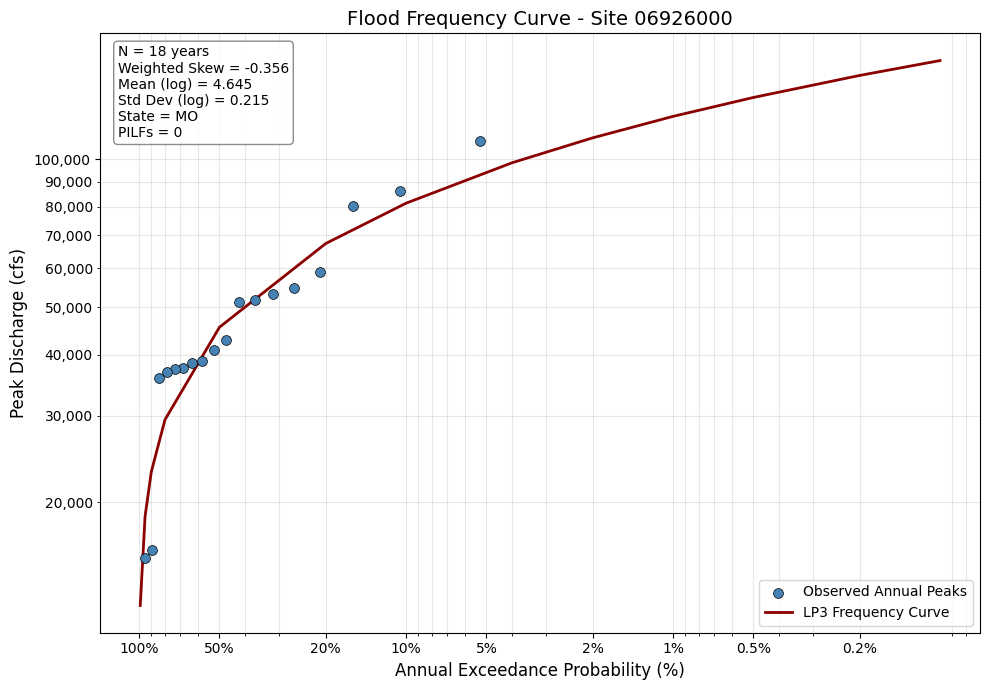

In [137]:
plot_flood_frequency_curve(annual_peaks_sfd, lp3_results, inv_gauge_site_id)

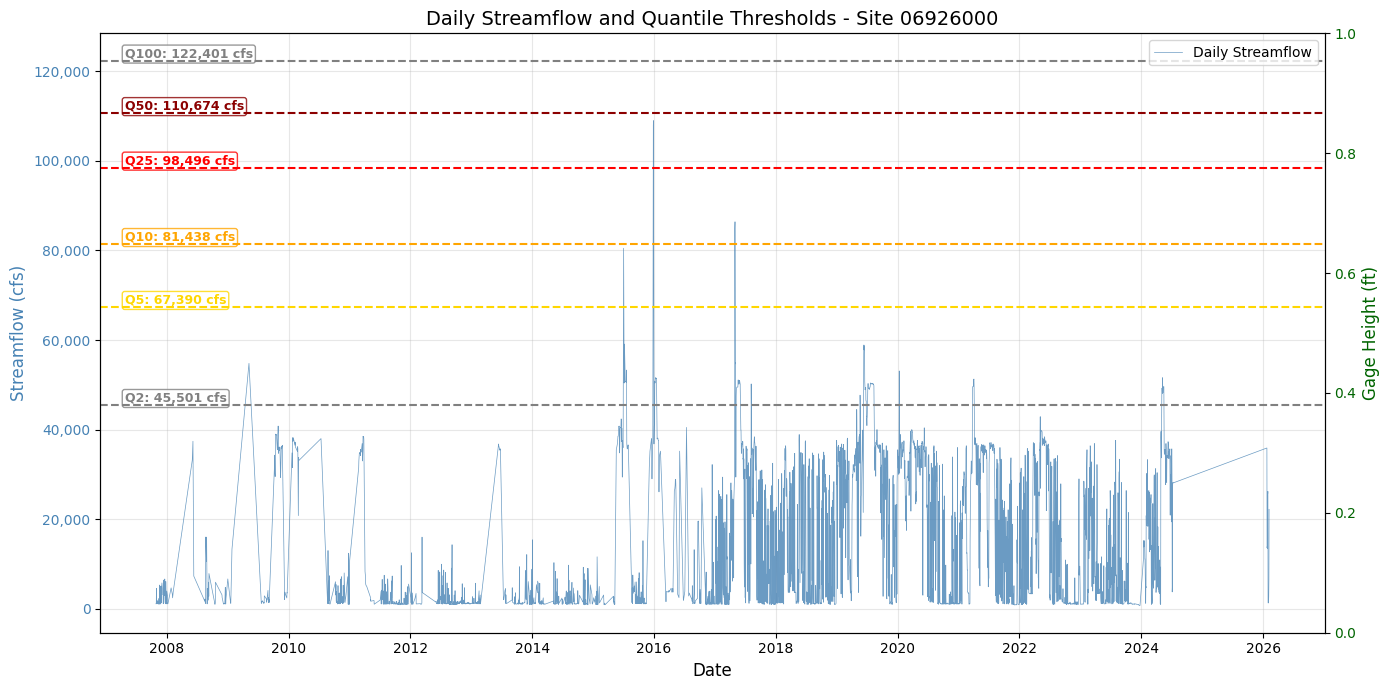

In [140]:
# Usage:
plot_daily_streamflow_with_thresholds(sfd_df, lp3_results, inv_gauge_site_id)

In [121]:
print(annual_peaks_sfd.filter(pl.col("site_id") == inv_gauge_site_id))

shape: (17, 4)
┌──────────┬──────┬────────────────────┬────────────┐
│ site_id  ┆ year ┆ peak_discharge_cfs ┆ peak_date  │
│ ---      ┆ ---  ┆ ---                ┆ ---        │
│ str      ┆ i32  ┆ f64                ┆ date       │
╞══════════╪══════╪════════════════════╪════════════╡
│ 06402500 ┆ 2008 ┆ 214.0              ┆ 2008-07-18 │
│ 06402500 ┆ 2009 ┆ 23.0               ┆ 2009-06-14 │
│ 06402500 ┆ 2010 ┆ 206.0              ┆ 2010-05-24 │
│ 06402500 ┆ 2011 ┆ 41.2               ┆ 2011-05-20 │
│ 06402500 ┆ 2012 ┆ 16.4               ┆ 2012-05-05 │
│ 06402500 ┆ 2013 ┆ 27.2               ┆ 2013-07-08 │
│ 06402500 ┆ 2014 ┆ 108.0              ┆ 2014-09-30 │
│ 06402500 ┆ 2015 ┆ 229.0              ┆ 2015-05-25 │
│ 06402500 ┆ 2016 ┆ 23.2               ┆ 2016-07-01 │
│ 06402500 ┆ 2017 ┆ 18.8               ┆ 2016-12-30 │
│ 06402500 ┆ 2018 ┆ 69.2               ┆ 2018-06-20 │
│ 06402500 ┆ 2019 ┆ 250.0              ┆ 2019-03-12 │
│ 06402500 ┆ 2020 ┆ 21.7               ┆ 2019-10-01 │
│ 06402500 ┆ 

In [104]:
with pl.Config(tbl_cols=-1):
    print(lp3_results.filter(pl.col("site_id") == inv_gauge_site_id))

shape: (1, 34)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ sit ┆ sta ┆ n_y ┆ mea ┆ std ┆ sta ┆ sta ┆ reg ┆ reg ┆ wei ┆ pil ┆ pil ┆ n_p ┆ n_r ┆ Q2_ ┆ flo ┆ Q5_ ┆ flo ┆ Q10 ┆ flo ┆ Q25 ┆ flo ┆ Q50 ┆ flo ┆ Q10 ┆ flo ┆ lat ┆ lon ┆ flo ┆ flo ┆ flo ┆ flo ┆ flo ┆ flo │
│ e_i ┆ te  ┆ ear ┆ n_l ┆ _lo ┆ tio ┆ tio ┆ ion ┆ ion ┆ ght ┆ f_t ┆ f_t ┆ ilf ┆ eta ┆ cfs ┆ ods ┆ cfs ┆ ods ┆ _cf ┆ ods ┆ _cf ┆ ods ┆ _cf ┆ ods ┆ 0_c ┆ ods ┆ itu ┆ git ┆ ods ┆ ods ┆ ods ┆ ods ┆ ods ┆ ods │
│ d   ┆ --- ┆ s   ┆ og  ┆ g   ┆ n_s ┆ n_m ┆ al_ ┆ al_ ┆ ed_ ┆ hre ┆ hre ┆ s   ┆ ine ┆ --- ┆ _Q2 ┆ --- ┆ _Q5 ┆ s   ┆ _Q1 ┆ s   ┆ _Q2 ┆ s   ┆ _Q5 ┆ fs  ┆ _Q1 ┆ de  ┆ ude ┆ _Q2 ┆ _Q5 ┆ _Q1 ┆ _Q2 ┆ _Q5 ┆ _Q1 │
│ --- ┆ str ┆ --- ┆ --- ┆ --- ┆ kew ┆ se  ┆ ske ┆ mse ┆ ske ┆ sho ┆ sho ┆ --- ┆ d   ┆ f64 ┆ --- ┆ f64 ┆ --- ┆ --- ┆ 0   ┆ --- ┆ 5   ┆ --- ┆ 0   ┆ --- ┆ 00  ┆ ---

In [141]:
del sfd_df, artifact, artifact_dir
gc.collect()

42333